# Credit Approval (UCI crx)

## SECCIÓN 0 — DESCRIPCIÓN DEL DATASET

Solicitudes de tarjeta de crédito; **atributos anonimizados** (A1–A15) por confidencialidad.

### Tarea de machine learning
- **Tipo de tarea**: clasificación binaria
- **Variable objetivo**: Última columna: `+` aprobado, `-` rechazado.

Las siguientes celdas cargan datos y muestran `head`, `shape`, `dtypes` y `describe`.

In [1]:
import warnings  # Avisos
warnings.filterwarnings("ignore")  # Ocultar
from pathlib import Path  # Rutas
import numpy as np  # Numerico
import pandas as pd  # Tablas
import matplotlib.pyplot as plt  # Graficos
import seaborn as sns  # Stats
from IPython.display import display  # Jupyter
from sklearn.model_selection import train_test_split  # Split
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Escalado
from sklearn.linear_model import LinearRegression, LogisticRegression  # Modelos
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score  # Metricas
ROOT_NB = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia")  # Raiz proyecto

df = pd.read_csv(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/6. Credit Approval – UCI/credit+approval/crx.data", header=None, na_values="?")  # Sin cabecera
df.columns = [f"A{i}" for i in range(1, 16)] + ["target"]  # Nombres A1..A15 + target
display(df.head(10))  # Muestra
print(df.shape, df.dtypes)  # Info
display(df.describe(include="all").T)  # Stats


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.0,0,+
5,b,32.08,4.000,u,g,m,v,2.500,t,f,0,t,g,360.0,0,+
6,b,33.17,1.040,u,g,r,h,6.500,t,f,0,t,g,164.0,31285,+
7,a,22.92,11.585,u,g,cc,v,0.040,t,f,0,f,g,80.0,1349,+
8,b,54.42,0.500,y,p,k,h,3.960,t,f,0,f,g,180.0,314,+
9,b,42.50,4.915,y,p,w,v,3.165,t,f,0,t,g,52.0,1442,+


(690, 16) A1            str
A2        float64
A3        float64
A4            str
A5            str
A6            str
A7            str
A8        float64
A9            str
A10           str
A11         int64
A12           str
A13           str
A14       float64
A15         int64
target        str
dtype: object


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1,678,2,b,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2,678.0,NaN,NaN,NaN,31.568171,11.957862,13.75,22.6025,28.46,38.23,80.25
A3,690.0,NaN,NaN,NaN,4.758725,4.978163,0.0,1.0,2.75,7.2075,28.0
A4,684,3,u,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A5,684,3,g,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A6,681,14,c,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A7,681,9,v,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A8,690.0,NaN,NaN,NaN,2.223406,3.346513,0.0,0.165,1.0,2.625,28.5
A9,690,2,t,361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10,690,2,f,395,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## SECCIÓN 1

In [2]:
df1 = df.copy()  # Copia para limpiar
print("Nulos ANTES por columna (top):\n", df1.isnull().sum().sort_values(ascending=False).head(15))  # Conteo
df1 = df1.drop_duplicates()  # Eliminar filas duplicadas
nr = df1.isnull().mean()  # Fraccion nulos
drop_null = nr[nr > 0.40].index.tolist()  # Columnas >40% nulos
print("Eliminadas por >40% nulos:", drop_null)  # Motivo: poca informacion
df1 = df1.drop(columns=drop_null, errors="ignore")  # Borrar
num_cols = df1.select_dtypes(include=[np.number]).columns.tolist()  # Numericas
cat_cols = [c for c in df1.columns if c not in num_cols]  # Categoricas
for c in num_cols:
    df1[c] = df1[c].fillna(df1[c].median())  # Mediana (robusta a outliers)
for c in cat_cols:
    if df1[c].isnull().any():
        mod = df1[c].mode()
        df1[c] = df1[c].fillna(mod.iloc[0] if len(mod) else "")  # Moda
print("Nulos DESPUES (total):", int(df1.isnull().sum().sum()))  # Debe ser 0
assert df1.isnull().sum().sum() == 0
df_clean = df1.copy()


Nulos ANTES por columna (top):
 A14    13
A1     12
A2     12
A7      9
A6      9
A5      6
A4      6
A3      0
A8      0
A9      0
A11     0
A10     0
A12     0
A13     0
A15     0
dtype: int64
Eliminadas por >40% nulos: []
Nulos DESPUES (total): 0


## SECCIÓN 2

y = `target` (+/-).

X.shape (690, 15) y.shape (690,)
target
0    383
1    307
Name: count, dtype: int64


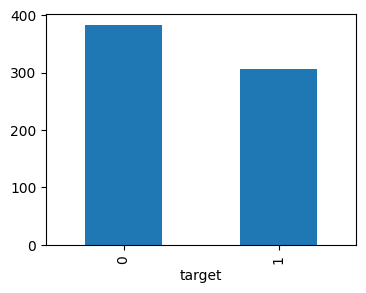

Top 5: A11    0.406410
A8     0.322475
A3     0.206294
A15    0.175657
A2     0.164086
dtype: float64


In [3]:
y = (df_clean["target"] == "+").astype(int)  # 1 aprobado
X = df_clean.drop(columns=["target"])  # Features
print("X.shape", X.shape, "y.shape", y.shape)  # Shapes
print(y.value_counts())  # Distribucion
plt.figure(figsize=(4,3))  # Figura
y.value_counts().plot(kind="bar")  # Barras
plt.show()  # Grafico
num_x = X.select_dtypes(include=[np.number]).columns  # Numericas
if len(num_x) > 0:
    corr = X[num_x].corrwith(y).abs().sort_values(ascending=False)  # Corr
    print("Top 5:", corr.head(5))  # Top 5


## SECCIÓN 3

In [4]:
X_enc = X.copy()  # Copia
non_num = [c for c in X_enc.columns if not pd.api.types.is_numeric_dtype(X_enc[c])]  # Categoricas
print("Categoricas (antes encoding):", non_num)  # Lista
X_enc = pd.get_dummies(X_enc, columns=non_num, drop_first=False)  # One-hot (nominal)
print("Columnas despues encoding:", X_enc.shape[1])  # Total
display(X_enc.head(5))  # Primeras filas


Categoricas (antes encoding): ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']
Columnas despues encoding: 46


,A2,A3,A8,A11,A14,A15,A1_a,A1_b,A4_l,A4_u,...,A7_z,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s
0,30.83,0.000,1.25,1,202.0,0,False,True,False,True,...,False,False,True,False,True,True,False,True,False,False
1,58.67,4.460,3.04,6,43.0,560,True,False,False,True,...,False,False,True,False,True,True,False,True,False,False
2,24.50,0.500,1.50,0,280.0,824,True,False,False,True,...,False,False,True,True,False,True,False,True,False,False
3,27.83,1.540,3.75,5,100.0,3,False,True,False,True,...,False,False,True,False,True,False,True,True,False,False
4,20.17,5.625,1.71,0,120.0,0,False,True,False,True,...,False,False,True,True,False,True,False,False,False,True


## SECCIÓN 4

In [5]:
scaler = StandardScaler()  # Escalador
X_scaled = scaler.fit_transform(X_enc)  # Ajuste global
X_scaled_df = pd.DataFrame(X_scaled, columns=X_enc.columns, index=X_enc.index)  # DF
antes = X_enc.iloc[:5, :min(6, X_enc.shape[1])]  # 5 filas antes
despues = X_scaled_df.iloc[:5, :min(6, X_scaled_df.shape[1])]  # 5 filas despues
display(pd.concat([antes, despues], axis=1, keys=["ANTES","DESPUES"]))  # Comparativa


ANTES                                DESPUES                                \
      A2     A3    A8 A11    A14  A15        A2        A3        A8       A11   
0  30.83  0.000  1.25   1  202.0    0 -0.057723 -0.956613 -0.291083 -0.288101   
1  58.67  4.460  3.04   6   43.0  560  2.291317 -0.060051  0.244190  0.740830   
2  24.50  0.500  1.50   0  280.0  824 -0.591826 -0.856102 -0.216324 -0.493887   
3  27.83  1.540  3.75   5  100.0    3 -0.310853 -0.647038  0.456505  0.535044   
4  20.17  5.625  1.71   0  120.0    0 -0.957176  0.174141 -0.153526 -0.493887   

                       
        A14       A15  
0  0.107155 -0.195413  
1 -0.816912 -0.087852  
2  0.560471 -0.037144  
3 -0.485643 -0.194837  
4 -0.369408 -0.195413

## SECCIÓN 5

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)  # Estratificado
print("Shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)  # Tamano


Shapes: (552, 46) (138, 46) (552,) (138,)


## SECCIÓN 6

In [7]:
clf = LogisticRegression(max_iter=1000)  # Modelo
clf.fit(X_train, y_train)  # Entrenar
acc = accuracy_score(y_test, clf.predict(X_test))  # Accuracy
print("Accuracy:", acc)  # Resultado
score_credit = acc  # Score


Accuracy: 0.855072463768116


## SECCIÓN 7

In [8]:
out = Path(r"C:/Users/Hp/OneDrive/Escritorio/primerparcial_ia/6. Credit Approval – UCI")  # Carpeta
pd.concat([X_scaled_df, y.rename("approved")], axis=1).to_csv(out / "credit_approval_clean.csv", index=False)  # Limpio
X_train.to_csv(out / "X_train.csv", index=False)  # Train
X_test.to_csv(out / "X_test.csv", index=False)  # Test
y_train.to_csv(out / "y_train.csv", index=True, header=True)  # y
y_test.to_csv(out / "y_test.csv", index=True, header=True)  # y test
print("Guardado credit_approval_clean.csv")  # Ok


Guardado credit_approval_clean.csv


## SECCIÓN 8

In [9]:
display(df_clean.head(10))  # Muestra
assert df_clean.isnull().sum().sum() == 0
print("RESUMEN Credit | Acc:", round(acc, 4))  # Resumen


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,target
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.0,0,+
5,b,32.08,4.000,u,g,m,v,2.500,t,f,0,t,g,360.0,0,+
6,b,33.17,1.040,u,g,r,h,6.500,t,f,0,t,g,164.0,31285,+
7,a,22.92,11.585,u,g,cc,v,0.040,t,f,0,f,g,80.0,1349,+
8,b,54.42,0.500,y,p,k,h,3.960,t,f,0,f,g,180.0,314,+
9,b,42.50,4.915,y,p,w,v,3.165,t,f,0,t,g,52.0,1442,+


RESUMEN Credit | Acc: 0.8551
